In [11]:
%pip install torch

#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_squared_error


In [12]:
# Load data from multiple batches to analyze drift

files = ["batch1.dat", "batch2.dat", "batch3.dat"]

dfs = []

for i, f in enumerate(files):
    df = pd.read_csv(f, sep=" ", header=None)
    df["batch"] = i   # track drift over time
    dfs.append(df)

# Combine all batches
data = pd.concat(dfs, ignore_index=True)

print("Shape of dataset:", data.shape)
print(data.head())


Shape of dataset: (3275, 130)
   0               1           2            3            4            5  \
0  1  1:15596.162100  2:1.868245   3:2.371604   4:2.803678   5:7.512213   
1  1  1:26402.070400  2:2.532401   3:5.411209   4:6.509906   5:7.658469   
2  1  1:42103.582000  2:3.454189   3:8.198175  4:10.508439  5:11.611003   
3  1  1:42825.988300  2:3.451192  3:12.113940  4:16.266853  5:39.910056   
4  1  1:58151.175700  2:4.194839  3:11.455096  4:15.715298  5:17.654915   

              6             7             8               9  ...  \
0   6:-2.739388   7:-3.344671   8:-4.847512  9:15326.691400  ...   
1   6:-4.722217   7:-5.817651   8:-7.518333  9:23855.781200  ...   
2   6:-7.668313   7:-9.478675  8:-12.230939  9:37562.300800  ...   
3   6:-7.849409   7:-9.689894  8:-11.921704  9:38379.066400  ...   
4  6:-11.083364  7:-13.580692  8:-16.407848  9:51975.589900  ...   

             120              121           122           123           124  \
0  120:-3.037772  121:3037.0390

In [13]:
# Rename columns for clarity
data.columns = [f"sensor_{i}" for i in range(data.shape[1]-1)] + ["batch"]

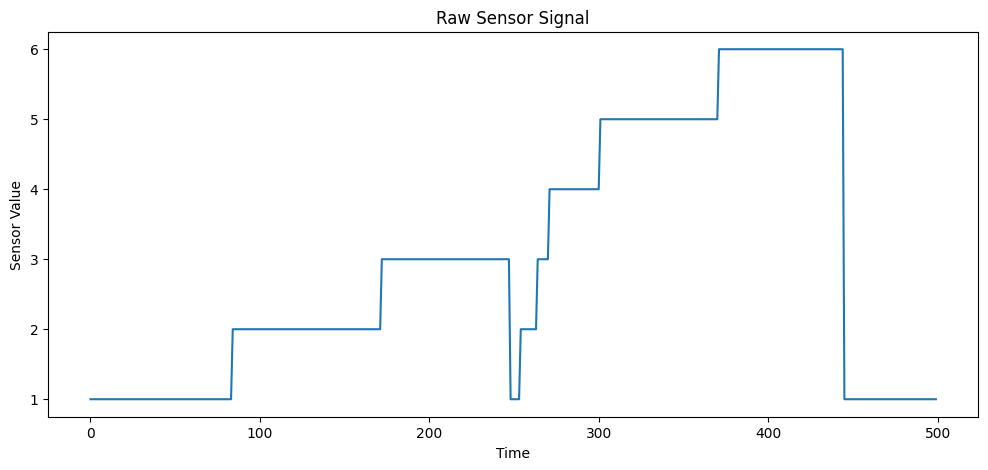

In [14]:
# Visualize raw sensor data to see drift
plt.figure(figsize=(12,5))
plt.plot(data["sensor_0"][:500])
plt.title("Raw Sensor Signal")
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.show()

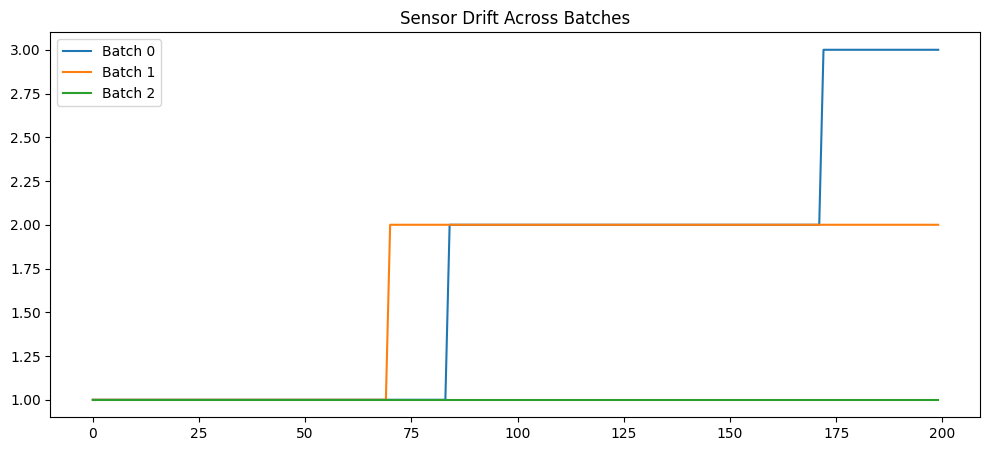

In [15]:
# Visualize drift across batches
plt.figure(figsize=(12,5))

for b in data["batch"].unique():
    subset = data[data["batch"] == b]
    plt.plot(subset["sensor_0"].values[:200], label=f"Batch {b}")

plt.title("Sensor Drift Across Batches")
plt.legend()
plt.show()


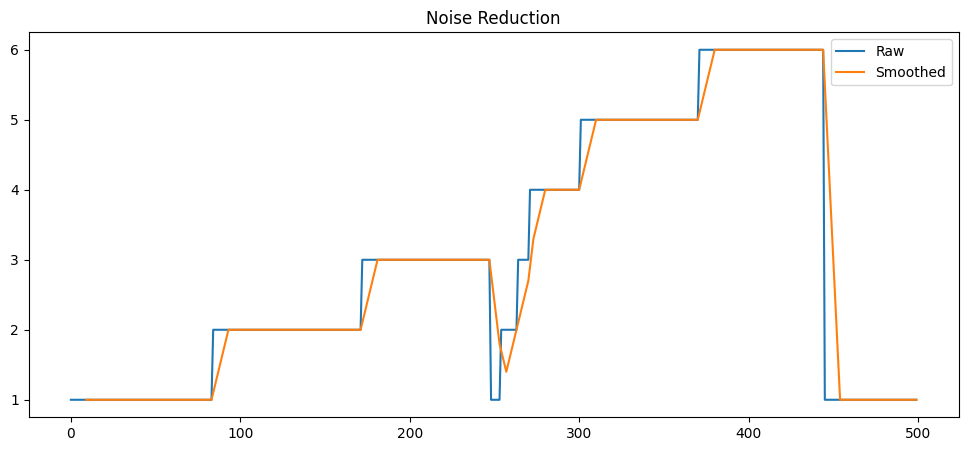

In [16]:
# Simple noise reduction using rolling mean
data["smooth"] = data["sensor_0"].rolling(window=10).mean()

plt.figure(figsize=(12,5))
plt.plot(data["sensor_0"][:500], label="Raw")
plt.plot(data["smooth"][:500], label="Smoothed")
plt.legend()
plt.title("Noise Reduction")
plt.show()

In [17]:
# Feature engineering: add rolling statistics
data["rolling_mean"] = data["sensor_0"].rolling(window=5).mean()
data["rolling_std"] = data["sensor_0"].rolling(window=5).std()

# Remove NaN values
data = data.dropna()


In [18]:
# The machine learning part: predict sensor_0 using rolling stats and batch as features
# Features and target
X = data[["rolling_mean", "rolling_std", "batch"]]
y = data["sensor_0"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 0.01865673171978724


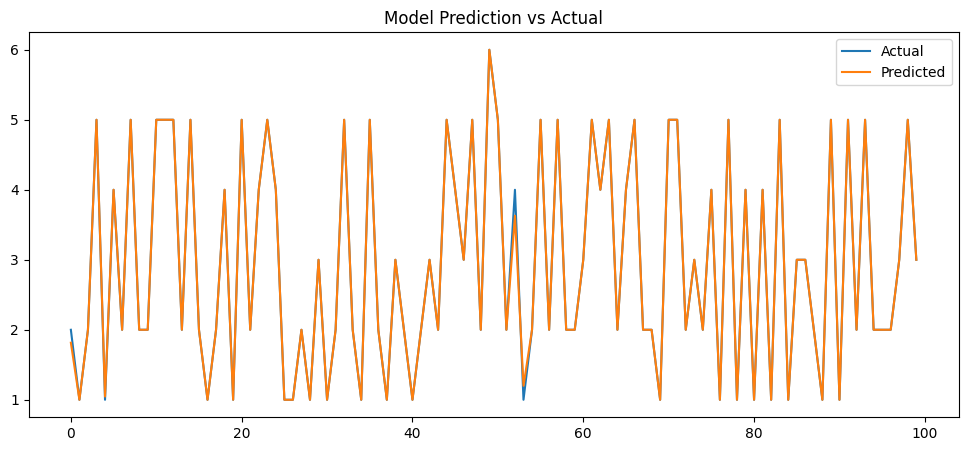

In [19]:
# Visualize predictions vs actual
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Model Prediction vs Actual")
plt.show()

In [20]:
# Anomaly detection using Isolation Forest
# Train Isolation Forest
iso_model = IsolationForest(contamination=0.05)
iso_model.fit(X)

# Predict anomalies
data["anomaly"] = iso_model.predict(X)

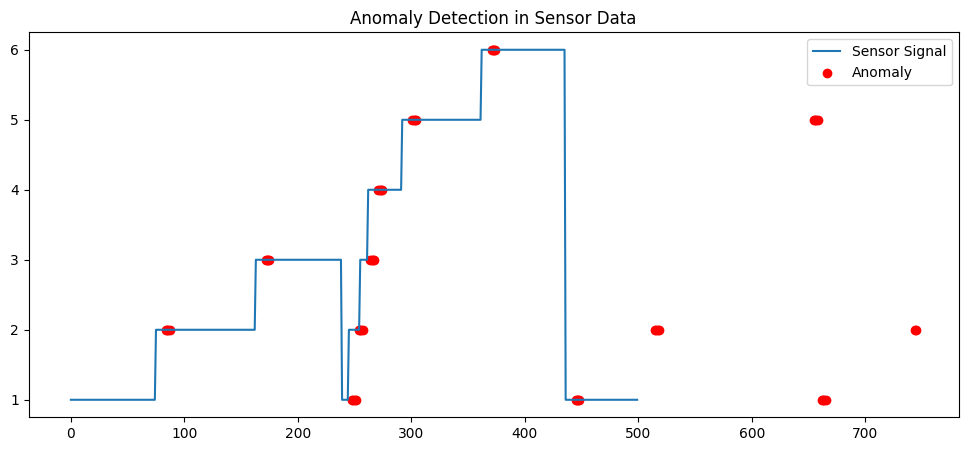

In [21]:
# Visualize anomalies
plt.figure(figsize=(12,5))

# Plot normal signal
plt.plot(data["sensor_0"].values[:500], label="Sensor Signal")

# Highlight anomalies
anomalies = data[data["anomaly"] == -1]

plt.scatter(anomalies.index[:50],
            anomalies["sensor_0"][:50],
            color='red',
            label='Anomaly')

plt.legend()
plt.title("Anomaly Detection in Sensor Data")
plt.show()